In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
import os
import pandas as pd
from PIL import Image
from skimage.feature import hog
from skimage import color
from tensorflow import keras

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split # Added import statement
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import gc

# ============================================
# Step 1: Mount Drive & Extract (Colab) — skip if running locally with data in extract_path
# ============================================
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except ImportError:
    pass

zip_path = "/content/drive/MyDrive/viechle.zip"
extract_path = "/content/dataset_v"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

BASE = extract_path
if not os.path.exists(os.path.join(BASE, 'Train')):
    for item in os.listdir(BASE):
        if os.path.exists(os.path.join(BASE, item, 'Train')):
            BASE = os.path.join(BASE, item)
            break

print(f"BASE: {BASE}")

# ============================================
# Step 2: Create DataFrames
# ============================================
train_dir = os.path.join(BASE, 'Train')
filepaths, labels = [], []

for folder in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, folder)
    if os.path.isdir(foldpath):
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(folder)

train_df = pd.DataFrame({'filepath': filepaths, 'label': labels})
# GTSRB train folders are often "00000".."00042"; test CSV uses 0..42 — must match for ImageDataGenerator
train_df['label'] = train_df['label'].astype(int).astype(str)

test_csv = pd.read_csv(os.path.join(BASE, 'Test.csv'))
test_df = pd.DataFrame({
    'filepath': test_csv['Path'].apply(
        lambda p: os.path.normpath(os.path.join(BASE, str(p).replace('\\', os.sep)))
    ),
    'label': test_csv['ClassId'].astype(int).astype(str)
})

# Some dataset copies use ClassId 1..43 instead of 0..42 — align with folder ids
cid = test_csv['ClassId'].astype(int)
if cid.min() >= 1 and cid.max() <= 43 and train_df['label'].astype(int).max() <= 42:
    test_df['label'] = (cid - 1).astype(str)

train_df = train_df[train_df['filepath'].apply(os.path.isfile)].reset_index(drop=True)
test_df = test_df[test_df['filepath'].apply(os.path.isfile)].reset_index(drop=True)

# Fixed mapping class id -> softmax index (avoids flow_from_dataframe + sparse + classes bugs)
sorted_class_ids = sorted(train_df['label'].unique(), key=lambda x: int(x))
class_to_idx = {cid: i for i, cid in enumerate(sorted_class_ids)}
missing_test = set(test_df['label'].unique()) - set(class_to_idx.keys())
if missing_test:
    raise ValueError(f'Test labels not in train: {missing_test}')
train_df['y'] = train_df['label'].map(class_to_idx).astype(np.int32)
test_df['y'] = test_df['label'].map(class_to_idx).astype(np.int32)

train_part, val_part = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['y'],
    random_state=42,
)

print(f"✅ train: {len(train_df)} | train_fit: {len(train_part)} | val: {len(val_part)} | test: {len(test_df)}")

# ============================================
# Step 3: Clean up RAM
# ============================================
gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/dataset_v
✅ train: 39209 | train_fit: 33327 | val: 5882 | test: 12630


0

In [5]:
CLASS_NAMES = {
    0:'Speed limit 20',    1:'Speed limit 30',     2:'Speed limit 50',
    3:'Speed limit 60',    4:'Speed limit 70',     5:'Speed limit 80',
    6:'End speed 80',      7:'Speed limit 100',    8:'Speed limit 120',
    9:'No passing',       10:'No passing >3.5t',  11:'Right of way jn.',
   12:'Priority road',    13:'Yield',              14:'Stop',
   15:'No vehicles',      16:'No veh >3.5t',      17:'No entry',
   18:'General caution',  19:'Danger curve L',     20:'Danger curve R',
   21:'Double curve',     22:'Bumpy road',         23:'Slippery road',
   24:'Narrow road R',    25:'Road works',         26:'Traffic signals',
   27:'Pedestrians',      28:'Children crossing',  29:'Bicycles crossing',
   30:'Beware of ice',    31:'Wild animals',       32:'End restrictions',
   33:'Turn right ahead', 34:'Turn left ahead',    35:'Ahead only',
   36:'Ahead or right',   37:'Ahead or left',      38:'Keep right',
   39:'Keep left',        40:'Roundabout',         41:'End no passing',
   42:'End no pass >3.5t'
}

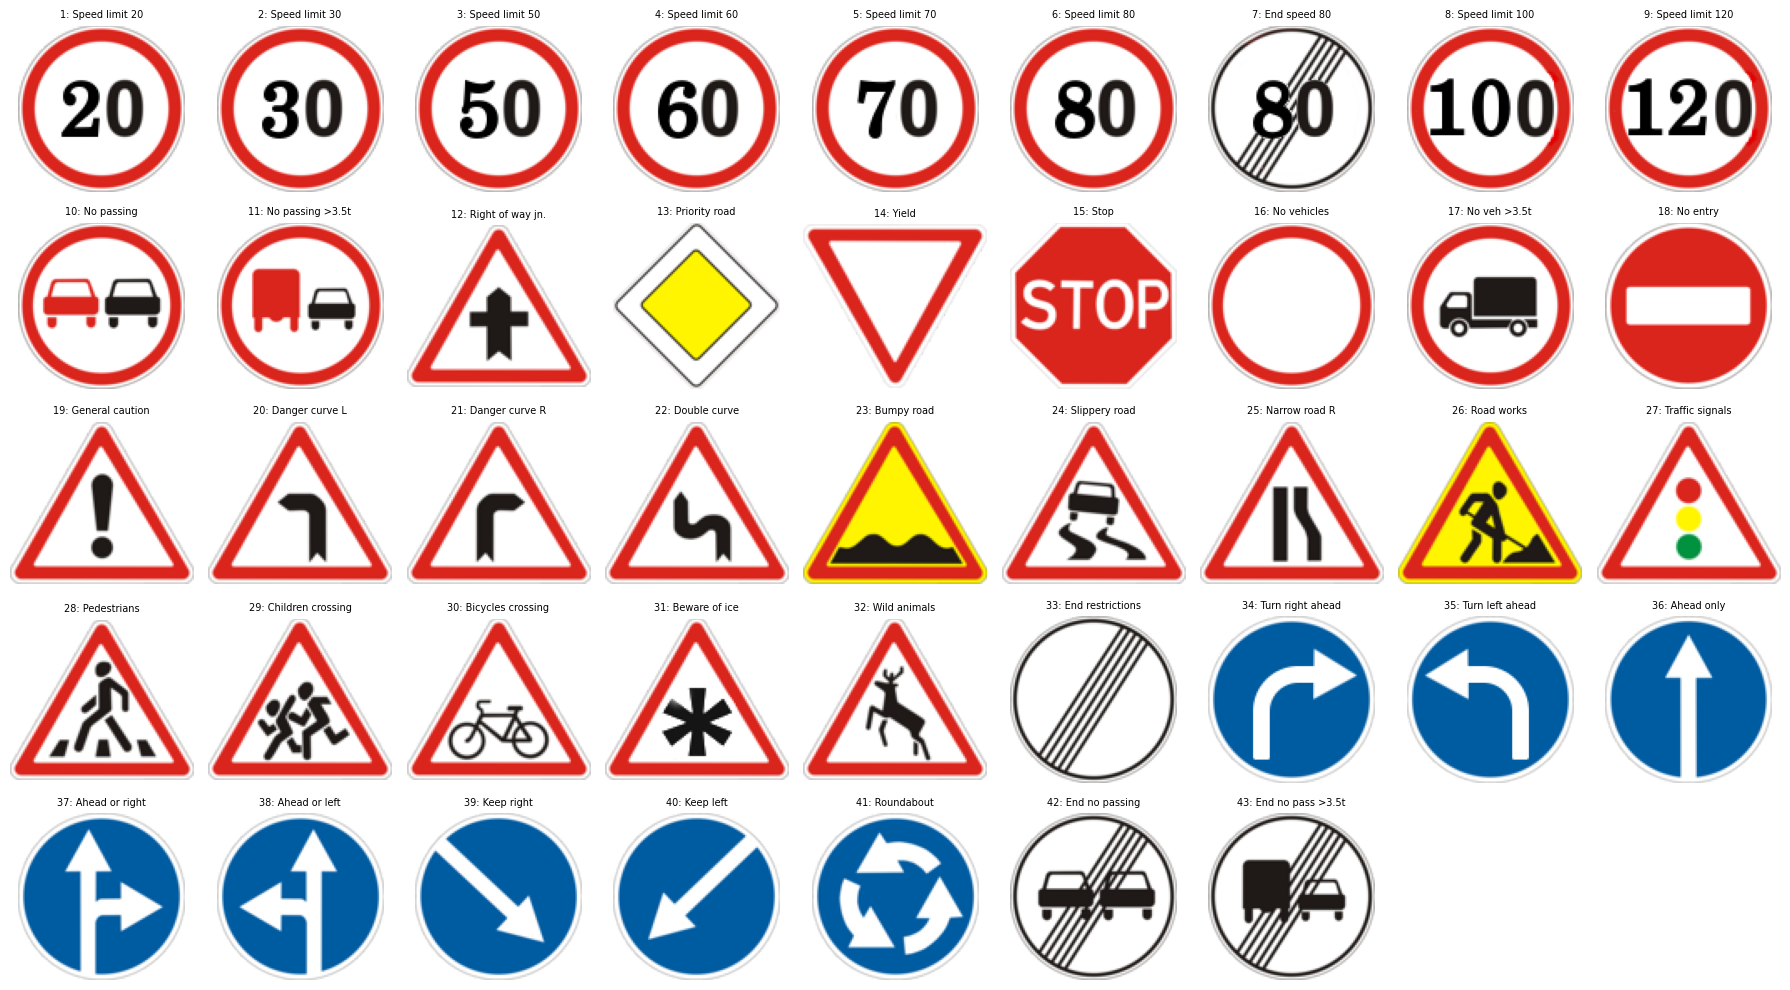

In [6]:
meta_path = os.path.join(BASE, "Meta")

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(43):
    img_path = os.path.join(meta_path, f"{class_id}.png")
    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"{class_id+1}: {CLASS_NAMES[class_id]}", fontsize=7)
    axes[class_id].axis("off")


for i in range(43, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


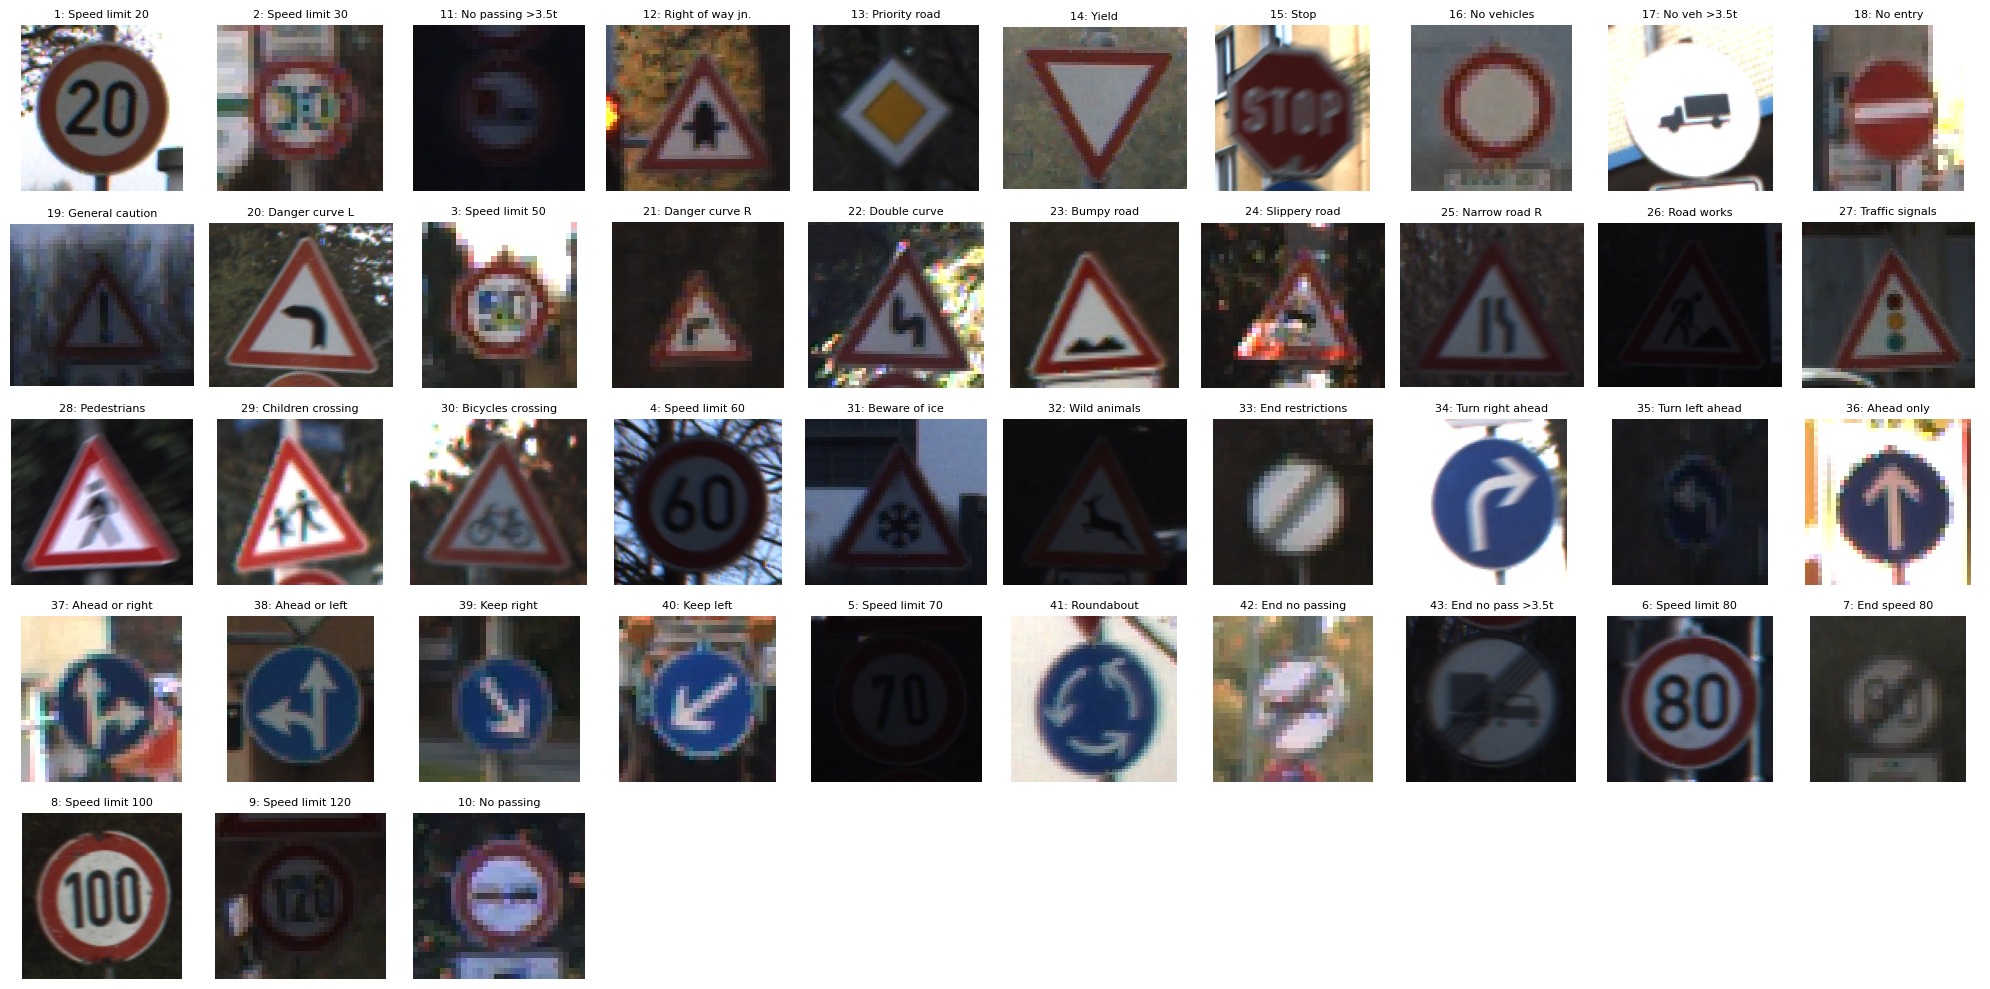

In [7]:
sample_df = train_df.groupby('label').first().reset_index()

n_samples = len(sample_df)

n_cols = 10
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_samples):
    img = Image.open(sample_df['filepath'][i])

    label = int(sample_df['label'][i])
    class_name = CLASS_NAMES[label]

    axes[i].imshow(img)
    axes[i].set_title(f"{label+1}: {class_name}", fontsize=8)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_11877/882057596.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


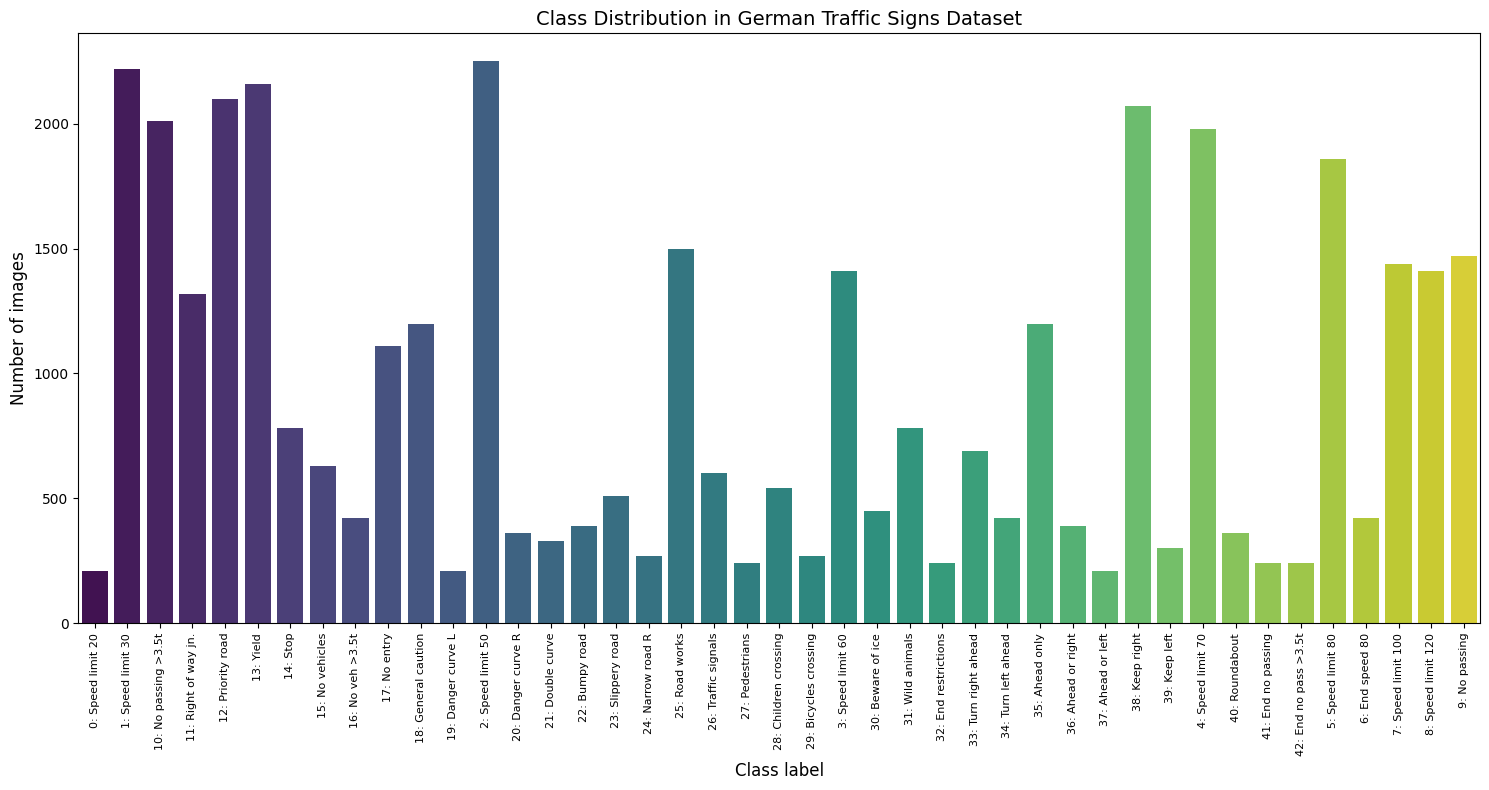

Total images: 39209
Total classes: 43
Average images per class: 911.84
Min images in a class: 210
Max images in a class: 2250


In [9]:
class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Class Distribution in German Traffic Signs Dataset', fontsize=14)

plt.xticks(ticks=range(len(class_counts)),
           labels=[f"{i}: {CLASS_NAMES[int(i)]}" for i in class_counts.index],
           rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {len(train_df)}")
print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {len(train_df)/len(class_counts):.2f}")
print(f"Min images in a class: {class_counts.min()}")
print(f"Max images in a class: {class_counts.max()}")

In [23]:
def preprocess_image(image_path, size=(32, 32)):
    img = Image.open(image_path)
    img_resized = img.resize(size)
    return np.array(img_resized)

# Extract edges and compute HOG features to capture shape and structure information, which is crucial for traffic sign recognition.
def extract_hog_features(image_array, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=8):
    img_gray = color.rgb2gray(image_array)
    fd = hog(img_gray,
             orientations=orientations,
             pixels_per_cell=pixels_per_cell,
             cells_per_block=cells_per_block,
             block_norm='L2-Hys',
             transform_sqrt=True,
             feature_vector=True)
    return fd

x_train = []
for filepath in train_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_train.append(hog_features)

x_train = np.array(x_train)

x_test = []
for filepath in test_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_test.append(hog_features)

x_test = np.array(x_test)

y_train = train_df['y'].values
y_test = test_df['y'].values

print(f"Feature vector size: {x_train.shape[1]}")
print(f"Train: {x_train.shape[0]} | Test: {x_test.shape[0]}")

Feature vector size: 288
Train: 39209 | Test: 12630


In [11]:
# Standardize the flattened pixel values
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
save_path = "features"
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "x_train.npy"), x_train)
np.save(os.path.join(save_path, "x_test.npy"), x_test)
np.save(os.path.join(save_path, "y_train.npy"), y_train)
np.save(os.path.join(save_path, "y_test.npy"), y_test)
np.save(os.path.join(save_path, "x_train_scaled.npy"), x_train_scaled)
np.save(os.path.join(save_path, "x_test_scaled.npy"), x_test_scaled)

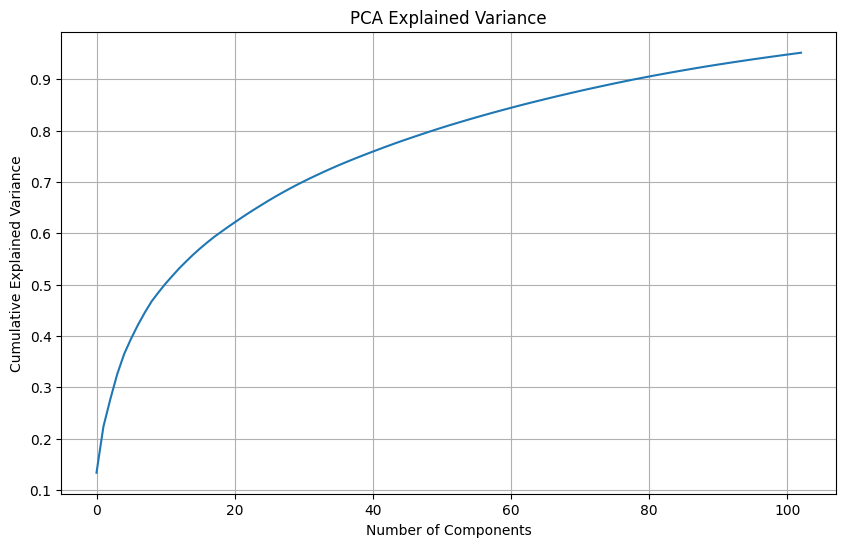

Components selected: 103


In [13]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [14]:
# KNN Without PCA
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_scaled, y_train.reshape(-1,))
y_KNN = KNN.predict(x_test_scaled)
print("KNN without PCA Accuracy:", accuracy_score(y_test, y_KNN))

# KNN with PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca,y_train.reshape(-1,))
y_KNN_pca = KNN_pca.predict(x_test_pca)
print("KNN with PCA Accuracy:", accuracy_score(y_test, y_KNN_pca))

KNN without PCA Accuracy: 0.6903404592240697
KNN with PCA Accuracy: 0.6896278701504355


In [15]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_scaled, y_train.reshape(-1,))
y_ModelNaive = ModelNaive.predict(x_test_scaled)
print("Naive Bayes without PCA Accuracy:", accuracy_score(y_test, y_ModelNaive))

# Naive Bayes with PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train.reshape(-1,))
y_ModelNaive_pca = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA Accuracy:", accuracy_score(y_test, y_ModelNaive_pca))

Naive Bayes without PCA Accuracy: 0.6855106888361046
Naive Bayes with PCA Accuracy: 0.728978622327791


In [16]:
# --- Without PCA ---
# Hard Voting (majority vote)
voting_clf = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='hard'
)
voting_clf.fit(x_train_scaled, y_train.reshape(-1,))
y_voting = voting_clf.predict(x_test_scaled)
print("Hard Voting without PCA Accuracy:", accuracy_score(y_test, y_voting))

# Soft Voting (average probabilities)
voting_clf_soft = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='soft'
)
voting_clf_soft.fit(x_train_scaled, y_train.reshape(-1,))
y_voting_soft = voting_clf_soft.predict(x_test_scaled)
print("Soft Voting without PCA Accuracy:", accuracy_score(y_test, y_voting_soft))

# --- With PCA ---
# Hard Voting (majority vote)
voting_clf_pca = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='hard'
)
voting_clf_pca.fit(x_train_pca, y_train.reshape(-1,))
y_voting_pca = voting_clf_pca.predict(x_test_pca)
print("Hard Voting with PCA Accuracy:", accuracy_score(y_test, y_voting_pca))

# Soft Voting (average probabilities)
voting_clf_soft_pca = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='soft'
)
voting_clf_soft_pca.fit(x_train_pca, y_train.reshape(-1,))
y_voting_soft_pca = voting_clf_soft_pca.predict(x_test_pca)
print("Soft Voting with PCA Accuracy:", accuracy_score(y_test, y_voting_soft_pca))

Hard Voting without PCA Accuracy: 0.6885193982581156
Soft Voting without PCA Accuracy: 0.7144893111638955
Hard Voting with PCA Accuracy: 0.7156769596199525
Soft Voting with PCA Accuracy: 0.7522565320665083


In [17]:
# Bagging with KNN - Without PCA
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10,
    random_state=42
)
bagging_knn.fit(x_train_scaled, y_train.reshape(-1,))
y_bagging_knn = bagging_knn.predict(x_test_scaled)
print("Bagging KNN without PCA Accuracy:", accuracy_score(y_test, y_bagging_knn))

# Bagging with Naive Bayes - Without PCA
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    random_state=42
)
bagging_nb.fit(x_train_scaled, y_train.reshape(-1,))
y_bagging_nb = bagging_nb.predict(x_test_scaled)
print("Bagging NB without PCA Accuracy:", accuracy_score(y_test, y_bagging_nb))

# Bagging with KNN - With PCA
bagging_knn_pca = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10,
    random_state=42
)
bagging_knn_pca.fit(x_train_pca, y_train.reshape(-1,))
y_bagging_knn_pca = bagging_knn_pca.predict(x_test_pca)
print("Bagging KNN with PCA Accuracy:", accuracy_score(y_test, y_bagging_knn_pca))

# Bagging with Naive Bayes - With PCA
bagging_nb_pca = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    random_state=42
)
bagging_nb_pca.fit(x_train_pca, y_train.reshape(-1,))
y_bagging_nb_pca = bagging_nb_pca.predict(x_test_pca)
print("Bagging NB with PCA Accuracy:", accuracy_score(y_test, y_bagging_nb_pca))

Bagging KNN without PCA Accuracy: 0.6907363420427554
Bagging NB without PCA Accuracy: 0.6858273950910531
Bagging KNN with PCA Accuracy: 0.6931116389548694
Bagging NB with PCA Accuracy: 0.7279493269992082


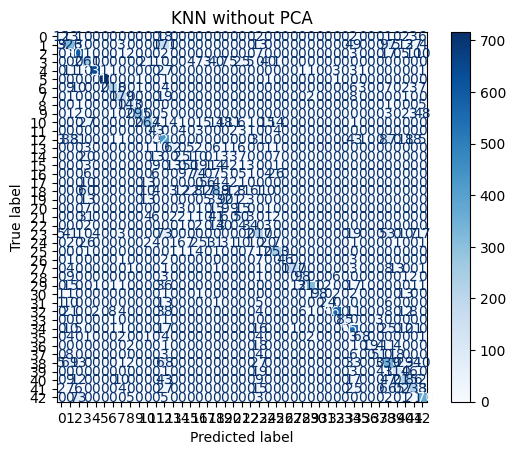

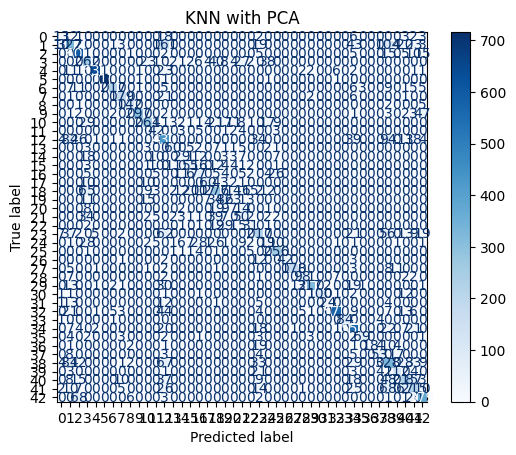

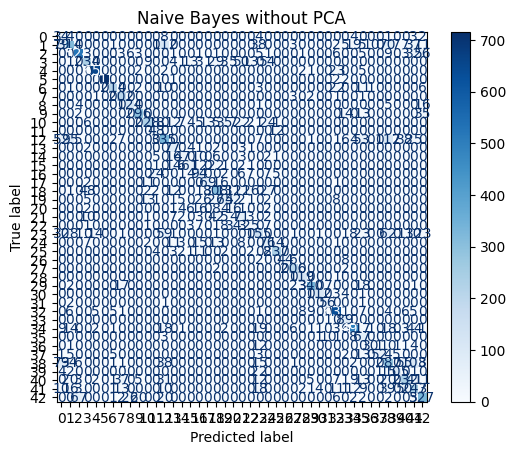

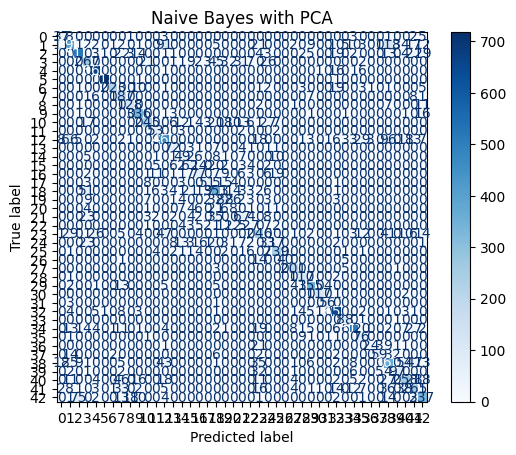

In [18]:
# Confusion Matrix
def confusion(y, y_pred , title):
    z= confusion_matrix(y, y_pred)
    d= ConfusionMatrixDisplay(confusion_matrix=z)
    d.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

confusion(y_test, y_KNN, "KNN without PCA")
confusion(y_test, y_KNN_pca, "KNN with PCA")

confusion(y_test, y_ModelNaive, "Naive Bayes without PCA")
confusion(y_test, y_ModelNaive_pca, "Naive Bayes with PCA")

In [19]:
# Loading raw images for CNN input
def load_images(df, size=(32, 32)):
    images = []
    for fp in df['filepath']:
        img = Image.open(fp).resize(size)
        img_array = np.array(img)
        if img_array.ndim == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        if img_array.shape[-1] == 4:
            img_array = img_array[:, :, :3]
        images.append(img_array)
    return np.array(images) / 255.0

x_train_img = load_images(train_df)
x_test_img  = load_images(test_df)
print("Image train shape:", x_train_img.shape)
print("Image test shape :", x_test_img.shape)

Image train shape: (39209, 32, 32, 3)
Image test shape : (12630, 32, 32, 3)


In [20]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_cnn(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
histories = {}

for name, optimizer in [
    ('Adam', keras.optimizers.Adam()),
    ('SGD',  keras.optimizers.SGD(0.01, momentum=0.9))
]:
    m = build_cnn()
    m.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = m.fit(x_train_img, y_train, epochs=10, batch_size=64, validation_data=(x_test_img, y_test), verbose=1)
    histories[name] = (m, hist)

# Plot comparison
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
for name, (_, h) in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Optimizer Comparison - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
for name, (_, h) in histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.title('Optimizer Comparison - Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/10
558/613 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 0.4669 - loss: 2.0851

KeyboardInterrupt: 

In [ ]:
model = histories['Adam'][0] # Using the best performing model (Adam) for visualization

layer_outputs = [l.output for l in model.layers if 'conv2d' in l.name]
activation_model = keras.Model(inputs=model.inputs, outputs=layer_outputs)

sample = x_test_img[0:1]
activations = activation_model.predict(sample)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(activations[0][0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('Conv Layer 1 - Feature Maps')
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

base_model = MobileNetV2(input_shape=(32,32,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
out = layers.Dense(43, activation='softmax')(x)

mobilenet_model = Model(base_model.input, out)
mobilenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Training with frozen base ---")
hist_frozen = mobilenet_model.fit(x_train_img, y_train, epochs=10, batch_size=64, validation_data=(x_test_img, y_test))

print("--- Fine-tuning (unfrozen) ---")
base_model.trainable = True
mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_ft = mobilenet_model.fit(x_train_img, y_train, epochs=5, batch_size=64, validation_data=(x_test_img, y_test))

In [ ]:
scaler = MinMaxScaler()
x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

# NOISE
def gaussian_noise(features, noise_factor):
    noisy_features = features + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=features.shape)
    noisy_features = np.clip(noisy_features, 0., 1.)
    return noisy_features

# salt and peper noise
def salt_peper(features, dropout_rate):
    noisy_features = np.copy(features)
    mask = np.random.binomial(1, 1 - dropout_rate, size=features.shape)
    noisy_features = noisy_features * mask
    return noisy_features

x_train_noisy = gaussian_noise(x_train_normalized, noise_factor=0.4)
x_train_noisy = salt_peper(x_train_noisy, dropout_rate=0.2)

x_test_noisy = gaussian_noise(x_test_normalized, noise_factor=0.4)
x_test_noisy = salt_peper(x_test_noisy, dropout_rate=0.2)

print(f"Noisy train features shape: {x_train_noisy.shape}")
print(f"Noisy test features shape: {x_test_noisy.shape}")

In [ ]:
def build_dense_autoencoder(input_dim):
    input_layer = layers.Input(shape=(input_dim,))

    # Encoding layers
    encoded = layers.Dense(256, activation='relu')(input_layer)
    encoded = layers.Dense(128, activation='relu')(encoded)
    encoded = layers.Dense(64, activation='relu')(encoded)

    # Decoding layers
    decoded = layers.Dense(128, activation='relu')(encoded)
    decoded = layers.Dense(256, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = keras.Model(input_layer, decoded)

    return autoencoder

feature_dim = x_train.shape[1]
autoencoder = build_dense_autoencoder(feature_dim)
autoencoder.summary()

# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse',
)

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train_normalized,
    epochs=100,
    batch_size=120,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_normalized),
    verbose=1
)

In [ ]:
# Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

In [ ]:
print("\nGenerating reconstructed features")
x_train_reconstructed = autoencoder.predict(x_train_noisy)
x_test_reconstructed = autoencoder.predict(x_test_noisy)

n_samples = 15
sample_indices = np.random.choice(len(x_test_normalized), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(30, 9))

for i, idx in enumerate(sample_indices):
    #clean features
    axes[0, i].plot(x_test_normalized[idx], linewidth=1)
    axes[0, i].set_ylim([0, 1])
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    if i == 0:
        axes[0, i].set_ylabel('Original\nClean', fontsize=10, fontweight='bold')

    #Noisy features
    axes[1, i].plot(x_test_noisy[idx], linewidth=1, color='orange')
    axes[1, i].set_ylim([0, 1])
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    if i == 0:
        axes[1, i].set_ylabel('Noisy\nInput', fontsize=10, fontweight='bold')

    # Reconstructed Features
    axes[2, i].plot(x_test_reconstructed[idx], linewidth=1, color='green')
    axes[2, i].set_ylim([0, 1])
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])
    if i == 0:
        axes[2, i].set_ylabel('Reconstructed\nOutput', fontsize=10, fontweight='bold')

    axes[0, i].set_title(f'Class {y_test[idx]}', fontsize=9)

plt.suptitle('AutoEncoder - HOG feature reconstruction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_train = np.mean((x_train_normalized - x_train_reconstructed) ** 2)

mse_test = np.mean((x_test_normalized - x_test_reconstructed) ** 2)

In [ ]:
print(f"\n{'='*60}")
print(f"PERFORMANCE - HOG feature Reconstruction")
print(f"{'='*60}")
print(f"Training Set:")
print(f"  Mean squared error : {mse_train:.6f}")
print(f"\nTest Set:")
print(f"  Mean squared error : {mse_test:.6f}")
print(f"{'='*60}")

In [ ]:
import os
import json
import joblib
import numpy as np
from tensorflow import keras
from google.colab import drive
drive.mount('/content/drive')

# =====================
# PATHS
# =====================
base_path = "/content/drive/MyDrive/ai_project_v"
model_path = os.path.join(base_path, "models")
features_path = os.path.join(base_path, "features")



# =====================
# 2. LOAD SCALER
# =====================
scaler = joblib.load(
    os.path.join(model_path, "scaler.pkl")
)

print("Scaler loaded ✔")

# =====================
# 3. LOAD FEATURES
# =====================
x_train_reconstructed = np.load(
    os.path.join(features_path, "x_train_reconstructed.npy")
)

x_test_reconstructed = np.load(
    os.path.join(features_path, "x_test_reconstructed.npy")
)

x_train_noisy = np.load(
    os.path.join(features_path, "x_train_noisy.npy")
)

x_test_noisy = np.load(
    os.path.join(features_path, "x_test_noisy.npy")
)

print("Features loaded ✔")

# =====================
# 4. LOAD HISTORY
# =====================
with open(os.path.join(base_path, "history.json"), "r") as f:
    history = json.load(f)

print("History loaded ✔")

# =====================
# 5. LOAD METRICS
# =====================
with open(os.path.join(base_path, "results.txt"), "r") as f:
    results = f.read()

print("Metrics loaded ✔")
print(results)

# =====================
# DONE
# =====================
print("Everything loaded successfully 🚀")

In [ ]:
import numpy as np
import os

# ============================================
# Set the path where features are saved
# ============================================
save_path = "features"

# If using Google Colab with Drive:
# save_path = "/content/drive/MyDrive/ai_project_v/features"

# ============================================
# Load all saved features
# ============================================

# HOG features (raw)
x_train = np.load(os.path.join(save_path, "x_train.npy"))
x_test = np.load(os.path.join(save_path, "x_test.npy"))

# Labels
y_train = np.load(os.path.join(save_path, "y_train.npy"))
y_test = np.load(os.path.join(save_path, "y_test.npy"))

# Scaled HOG features
x_train_scaled = np.load(os.path.join(save_path, "x_train_scaled.npy"))
x_test_scaled = np.load(os.path.join(save_path, "x_test_scaled.npy"))

# ============================================
# Verify everything loaded correctly
# ============================================
print("=" * 50)
print("ALL FEATURES LOADED SUCCESSFULLY ✅")
print("=" * 50)
print(f"x_train shape:        {x_train.shape}")
print(f"x_test shape:         {x_test.shape}")
print(f"y_train shape:        {y_train.shape}")
print(f"y_test shape:         {y_test.shape}")
print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"x_test_scaled shape:  {x_test_scaled.shape}")
print(f"\nNumber of classes:    {len(np.unique(y_train))}")
print(f"Feature vector size:  {x_train.shape[1]}")

In [ ]:
import joblib
import json

# Paths
base_path = ""
model_path = os.path.join(base_path, "models")
os.makedirs(model_path, exist_ok=True)

# 1. Save Autoencoder Model
autoencoder.save(os.path.join(model_path, "autoencoder.h5"))

# 2. Save Encoder Only (Feature Extractor)
encoder = keras.Model(autoencoder.input, autoencoder.layers[3].output)
encoder.save(os.path.join(model_path, "encoder.h5"))

# 3. Save Scaler
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))

# 4. Save Reconstructed Features
features_path = os.path.join(base_path, "features")

np.save(os.path.join(features_path, "x_train_reconstructed.npy"), x_train_reconstructed)
np.save(os.path.join(features_path, "x_test_reconstructed.npy"), x_test_reconstructed)

# 5. Save Noisy Data
np.save(os.path.join(features_path, "x_train_noisy.npy"), x_train_noisy)
np.save(os.path.join(features_path, "x_test_noisy.npy"), x_test_noisy)

# 6. Save Training History
with open(os.path.join(base_path, "history.json"), "w") as f:
    json.dump(history.history, f)

# 7. Save Metrics
with open(os.path.join(base_path, "results.txt"), "w") as f:
    f.write(f"Train MSE: {mse_train}\n")
    f.write(f"Test MSE: {mse_test}\n")

print("All new components saved successfully!")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 96+ works better with ImageNet weights than 64; use 224 if you have GPU memory
IMG_SIZE = (96, 96)
BATCH_SIZE = 16
NUM_CLASSES = len(class_to_idx)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05
)

# class_mode='raw' uses column 'y' as integer class index (must match softmax output order)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_part,
    x_col='filepath',
    y_col='y',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True
)

val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    dataframe=val_part,
    x_col='filepath',
    y_col='y',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

test_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='y',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model, callbacks
import numpy as np
from PIL import Image

# ============================================
# Step 1: Load images at a larger size (96x96)
# ============================================
# ============================================
# Lighter MobileNetV2 using alpha=0.35
# alpha reduces the number of filters → less RAM
# ============================================
def build_mobilenet_light(input_shape=(96, 96, 3), num_classes=43):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = build_mobilenet_light(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
model.summary()

In [ ]:
# ============================================
# DEBUG: Check data entering the model
# ============================================
x_batch, y_batch = next(train_generator)

print("=== GENERATOR BATCH CHECK ===")
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("x_batch dtype:", x_batch.dtype)
print("y_batch dtype:", y_batch.dtype)
print("x_batch min:", x_batch.min())
print("x_batch max:", x_batch.max())
print("First 10 labels:", y_batch[:10])

print("\n=== MODEL SHAPE CHECK ===")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

print("\n=== DATAFRAME LABEL CHECK ===")
print("Number of unique labels in train_df:", train_df['label'].nunique())
print("Sorted labels:", sorted(train_df['label'].unique(), key=lambda x: int(x))[:10], "...")

print("\n=== CONSISTENCY CHECKS ===")
print("Expected batch image shape:", (BATCH_SIZE, IMG_SIZE[0], IMG_SIZE[1], 3))
print("Actual batch image shape:  ", x_batch.shape)
print("Does x_batch match model input shape?",
      x_batch.shape[1:] == model.input_shape[1:])
print("Does model output match number of classes?",
      model.output_shape[-1] == NUM_CLASSES)
print("Does NUM_CLASSES match train_df labels?",
      NUM_CLASSES == train_df['label'].nunique())

# Show sample images
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)

    # Undo preprocess_input approximately for display
    img = (x_batch[i] + 1.0) / 2.0
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Label: {int(y_batch[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Phase 1: Frozen Base
# ============================================
print("=" * 60)
print("PHASE 1: Training with frozen base")
print("=" * 60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

history_frozen = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_generator.reset()
phase1_acc = model.evaluate(test_generator, verbose=0)
print(f"\n✅ Phase 1 Accuracy: {phase1_acc[1]:.4f}")


In [ ]:
# ============================================
# Phase 2: Fine-tune last 40 layers
# ============================================
print("=" * 60)
print("PHASE 2: Fine-tuning")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-40]:   # Only last 40 layers
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_generator.reset()
phase2_acc = model.evaluate(test_generator, verbose=0)
print(f"\n✅ Phase 2 Accuracy: {phase2_acc[1]:.4f}")

In [ ]:
# ============================================
# Predictions
# ============================================
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test = test_generator.classes

final_acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Final Accuracy: {final_acc:.4f}")

# ============================================
# Plot History
# ============================================
acc = history_frozen.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_frozen.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_frozen.history['loss'] + history_finetune.history['loss']
val_loss = history_frozen.history['val_loss'] + history_finetune.history['val_loss']
epochs_frozen = len(history_frozen.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, 'b-', label='Train')
axes[0].plot(val_acc, 'r-', label='Val')
axes[0].axvline(x=epochs_frozen, color='green', linestyle='--', label='Fine-tune')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss, 'b-', label='Train')
axes[1].plot(val_loss, 'r-', label='Val')
axes[1].axvline(x=epochs_frozen, color='green', linestyle='--', label='Fine-tune')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'MobileNetV2 (Acc: {final_acc:.4f})')
plt.tight_layout()
plt.show()

# ============================================
# Confusion Matrix
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title(f'MobileNetV2 Confusion Matrix (Acc: {final_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ============================================
# Save
# ============================================
save_dir = "/content/drive/MyDrive/ai_project_v/models"
os.makedirs(save_dir, exist_ok=True)
model.save(os.path.join(save_dir, "mobilenet_traffic_signs.h5"))
print("✅ Saved!")